# 08 — Regularization and Subset Selection
**Goal:** Solve the three problems that ordinary least squares cannot —
high variance, d > n, and uninterpretable models with too many coefficients.
Source: ISLR Ch6, Hastie-Tibshirani-Friedman Ch3, Bishop Ch3.3.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_regression
np.random.seed(8)

## 1. The three problems regularization solves

1. **Variance reduction.** With d ≈ n the OLS estimator is unbiased but
   very high variance. Shrinking β̂ toward zero reduces variance at the
   cost of a little bias — net win.
2. **The d > n case.** X⊤X is singular. OLS does not exist. Ridge gives a
   unique solution.
3. **Interpretability.** Lasso drives some coefficients exactly to zero,
   performing variable selection *automatically*.

The unified optimization problem is

    β̂ = argmin_β  (1/(2n)) ‖y - Xβ‖² + λ · penalty(β)

where penalty is one of:
  - L2: ‖β‖²       (ridge)
  - L1: ‖β‖₁       (lasso)
  - Elastic net: α‖β‖² + (1 - α)‖β‖₁

## 2. Ridge regression — the L2 penalty

    β̂_ridge = argmin_β  ‖y - Xβ‖² + λ‖β‖²
             = (X⊤X + λI)⁻¹ X⊤y

The matrix X⊤X + λI is invertible for any λ > 0, so ridge always has a
solution. As λ → ∞, β̂ → 0. As λ → 0, β̂ → OLS.

**Crucial:** ridge is *not* scale-invariant. Always standardize features
before fitting (X ← (X - μ) / σ).

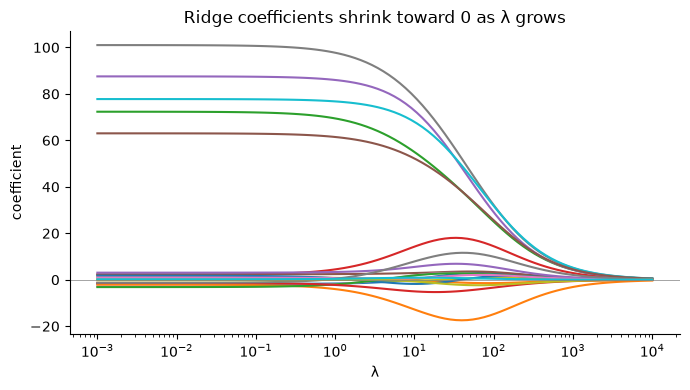

In [2]:
X, y = make_regression(n_samples=50, n_features=20, n_informative=5, noise=10, random_state=0)
fig, ax = plt.subplots(figsize=(7, 4))
coefs = []
for alpha in np.logspace(-3, 4, 100):
    m = make_pipeline(StandardScaler(), Ridge(alpha=alpha)).fit(X, y)
    coefs.append(m[-1].coef_)
coefs = np.array(coefs)
ax.plot(np.logspace(-3, 4, 100), coefs)
ax.set_xscale('log'); ax.set_xlabel('λ'); ax.set_ylabel('coefficient')
ax.set_title('Ridge coefficients shrink toward 0 as λ grows')
ax.axhline(0, color='gray', lw=0.5); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Lasso — the L1 penalty gives sparsity

    β̂_lasso = argmin_β  (1/2n)‖y - Xβ‖² + λ‖β‖₁

Because the L1 ball has corners, the optimum tends to land on a corner —
i.e. some coefficients are *exactly zero*. Lasso performs **soft** variable
selection.

No closed form; solved by coordinate descent (a few iterations of
soft-thresholding per coordinate).

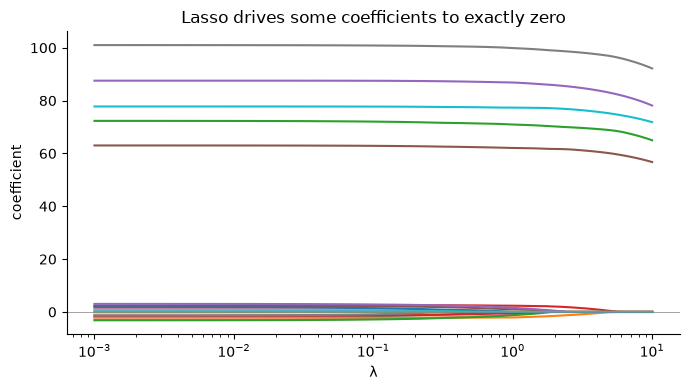

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
coefs = []
for alpha in np.logspace(-3, 1, 100):
    m = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=20000)).fit(X, y)
    coefs.append(m[-1].coef_)
coefs = np.array(coefs)
ax.plot(np.logspace(-3, 1, 100), coefs)
ax.set_xscale('log'); ax.set_xlabel('λ'); ax.set_ylabel('coefficient')
ax.set_title('Lasso drives some coefficients to exactly zero')
ax.axhline(0, color='gray', lw=0.5); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 4. The geometry of the three penalties

Picture the contours of the loss (ellipses) and the constraint region
(ball for L2, diamond for L1, mix for elastic net). The first place the
ellipse touches the region is the optimum.

- L2 ball is round → optimum is rarely exactly on an axis.
- L1 ball has corners → optimum is often at a corner, where some
  coordinates are zero.
- Elastic net combines both — group-correlated coefficients are selected
  together (Lasso alone tends to pick one of a group of correlated
  features).

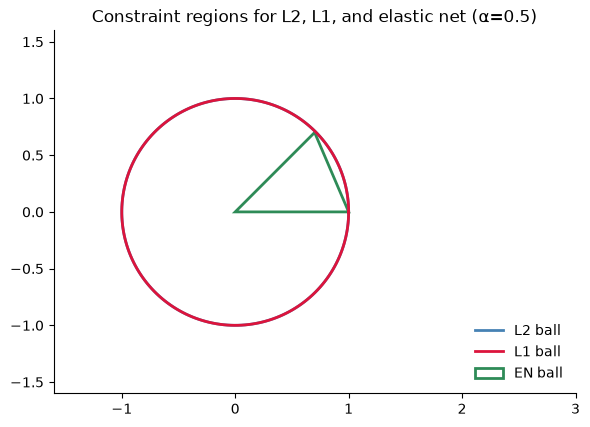

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color='steelblue', lw=2, label='L2 ball')
ax.plot(np.sign(np.cos(theta)) * np.abs(np.cos(theta)),
         np.sign(np.sin(theta)) * np.abs(np.sin(theta)), color='crimson', lw=2, label='L1 ball')
ax.add_patch(plt.Polygon([[0, 0], [0.7, 0.7], [1, 0]], fill=False, color='seagreen', lw=2, label='EN ball'))
ax.set_aspect('equal'); ax.legend(frameon=False, loc='lower right')
ax.set_xlim(-1.6, 3); ax.set_ylim(-1.6, 1.6)
ax.set_title('Constraint regions for L2, L1, and elastic net (α=0.5)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Why L1 selects and L2 does not — the KKT condition

For a single coefficient βⱼ with partial residual r, the L1 sub-gradient
condition is

    βⱼ  =  S(rⱼ, λ)  = sign(rⱼ) · max(|rⱼ| - λ, 0)

where S is the **soft-thresholding** operator. The L2 condition is

    βⱼ  =  rⱼ / (1 + λ)

Soft-thresholding creates a **dead zone** of width 2λ around zero — no
small coefficients can survive. This is the algebraic reason Lasso
sparsifies and Ridge does not.

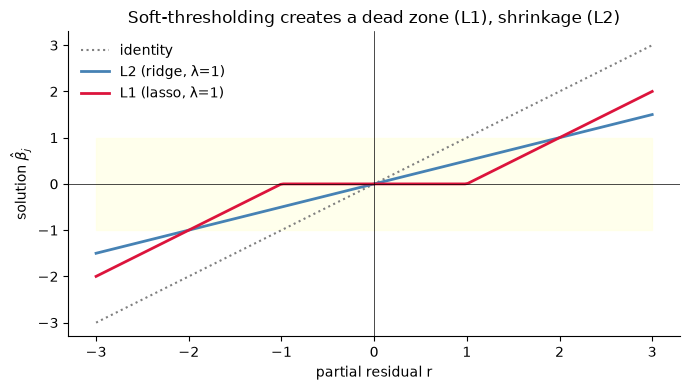

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
r = np.linspace(-3, 3, 200)
ax.plot(r, r, color='gray', linestyle=':', label='identity')
ax.plot(r, r/(1+1), color='steelblue', lw=2, label='L2 (ridge, λ=1)')
def soft(r, lam): return np.sign(r) * np.maximum(np.abs(r) - lam, 0)
ax.plot(r, soft(r, 1), color='crimson', lw=2, label='L1 (lasso, λ=1)')
ax.fill_between(r, -1, 1, color='lightyellow', alpha=0.6)
ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('partial residual r'); ax.set_ylabel(r'solution $\hat{\beta}_j$')
ax.set_title('Soft-thresholding creates a dead zone (L1), shrinkage (L2)')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 6. Choosing λ — cross-validation

Ridge and Lasso both have a free parameter λ. The standard approach is to
log-spaced grid of λ and pick the value that minimizes CV error (or use
the 1-SE rule). `RidgeCV` and `LassoCV` in sklearn do this.

In [6]:
from sklearn.linear_model import RidgeCV, LassoCV
alphas = np.logspace(-3, 4, 50)
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5)).fit(X, y)
lasso = make_pipeline(StandardScaler(), LassoCV(alphas=alphas, cv=5, max_iter=20000)).fit(X, y)
print(f'best ridge λ: {ridge[-1].alpha_:.4f}')
print(f'best lasso λ: {lasso[-1].alpha_:.4f}')
print(f'# non-zero lasso coefficients: {(lasso[-1].coef_ != 0).sum()} / {X.shape[1]}')

best ridge λ: 0.1931
best lasso λ: 1.3895
# non-zero lasso coefficients: 12 / 20


## 7. Subset selection and stepwise regression

The classical alternative to regularization is *subset selection*:

- **Best subset** — try all 2ᵈ subsets. Exact for d ≤ 40 with clever
  enumeration (Furnival & Wilson 1974); infeasible beyond.
- **Forward stepwise** — start empty, add the variable that most improves
  fit. O(d²) fits, easy.
- **Backward stepwise** — start full, drop the least useful. Same cost.
- **Hybrid** — forward, then backward at each step.

Stepwise is *worse* than Lasso in practice (Breiman 1996) — the search
ignores the multiple-comparisons issue. Use Lasso instead.

In [7]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=5, cv=5).fit(X, y)
print('forward-stepwise picked features:', np.where(sfs.get_support())[0])

forward-stepwise picked features: [ 2  4  7  9 15]


## 8. The Bayesian view of regularization

Ridge is the MAP estimate under a Gaussian prior on β (centered at 0):
  β ~ N(0, τ² I)
Lasso is the MAP estimate under a Laplace prior.
Elastic net is a Gaussian + Laplace mixture.

So **every regularizer is a prior**, and choosing λ is choosing prior
precision. This view is developed in notebooks 11 and 14.

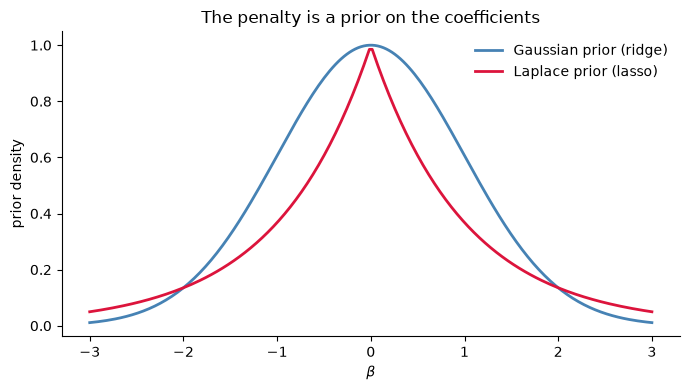

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.linspace(-3, 3, 200)
ax.plot(x, np.exp(-x**2/2),         color='steelblue', lw=2, label='Gaussian prior (ridge)')
ax.plot(x, np.exp(-np.abs(x)),       color='crimson',  lw=2, label='Laplace prior (lasso)')
ax.set_xlabel(r'$\beta$'); ax.set_ylabel('prior density')
ax.set_title('The penalty is a prior on the coefficients')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 9. Elastic Net — best of both worlds

    β̂_EN = argmin  ‖y - Xβ‖² + λ [α‖β‖² + (1 - α)‖β‖₁]

When features are correlated, Lasso tends to pick one and drop the others;
elastic net keeps groups of correlated features together. The parameter α
controls the L1/L2 mix (α=1 is Lasso, α=0 is Ridge).

In [9]:
from sklearn.linear_model import ElasticNetCV
m = make_pipeline(StandardScaler(),
                  ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 0.99], cv=5, max_iter=20000)).fit(X, y)
print(f'best l1_ratio: {m[-1].l1_ratio_:.2f}')
print(f'best alpha   : {m[-1].alpha_:.4f}')
print(f'# non-zero   : {(m[-1].coef_ != 0).sum()} / {X.shape[1]}')

best l1_ratio: 0.99
best alpha   : 0.9182
# non-zero   : 13 / 20


## 10. Practical advice

- **Always** standardize features before ridge/lasso/elastic net.
- **Always** tune λ by cross-validation.
- Prefer **Lasso** when you want interpretable sparse models.
- Prefer **Ridge** when all features are believed relevant and you have
  many small effects.
- Prefer **Elastic Net** when features are correlated and you have many
  features relative to n.
- For very high-dimensional data (p ≫ n), Lasso and Elastic Net are
  unbeatable. For very low-dimensional data, OLS is fine.
- **Don't** use stepwise regression — use Lasso instead.

In [10]:
# Comparison on a high-dim regression task
from sklearn.metrics import r2_score
X, y = make_regression(n_samples=80, n_features=200, n_informative=10, noise=15, random_state=0)
for name, m in [
    ('OLS',          make_pipeline(StandardScaler(), LinearRegression())),
    ('Ridge (CV)',   make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2,3,30), cv=5))),
    ('Lasso (CV)',   make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-3,1,30), cv=5, max_iter=20000))),
    ('EN (CV)',      make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.1,.5,.9], cv=5, max_iter=20000))),
]:
    s = cross_val_score(m, X, y, cv=5, scoring='r2')
    print(f'{name:14s}  R\u00b2 = {s.mean():.3f} \u00b1 {s.std():.3f}')

OLS             R² = 0.015 ± 0.179


Ridge (CV)      R² = 0.046 ± 0.091
Lasso (CV)      R² = 0.985 ± 0.002


EN (CV)         R² = 0.430 ± 0.070


## Summary

| Method | Penalty | Effect |
|---|---|---|
| Ridge | L2 | shrinks, never zeroes |
| Lasso | L1 | shrinks and selects |
| Elastic Net | L1 + L2 | selects groups of correlated features |
| Stepwise | none | poor practice; prefer Lasso |
| All of the above | all | CV-chosen λ is the right approach |

**Next:** `09_tree_based_methods.ipynb` — the second axis of modeling:
nonparametric, nonlinear, and the workhorse of applied ML.